In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
df = pd.read_csv("../../../data/processed/v1/strikers_top5leagues_features.csv")

In [31]:
df.head()

,league,season,team,player,nation,age,xg_per90,xa_per90,Standard_Sh/90,Standard_SoT/90,shot_conversion,goals_minus_xg,key_passes_per90,xg_chain_per90,xg_buildup_per90,finishing_share
0,ENG-Premier League,2526,Arsenal,Bukayo Saka,ENG,23,0.352275,0.346267,2.88,1.09,0.098592,-1.701196,2.510121,0.773788,0.325419,0.455261
1,ENG-Premier League,2526,Arsenal,Eberechi Eze,ENG,27,0.239177,0.131021,2.83,0.89,0.122807,2.192543,0.845771,0.515223,0.202690,0.464220
2,ENG-Premier League,2526,Arsenal,Gabriel Martinelli,BRA,24,0.446422,0.214098,2.41,1.08,0.034483,-4.357063,1.083333,0.835272,0.300543,0.534463
3,ENG-Premier League,2526,Arsenal,Kai Havertz,GER,26,0.753155,0.224151,2.79,0.62,0.111111,-2.895510,1.692308,0.695692,0.115637,1.082599
4,ENG-Premier League,2526,Arsenal,Leandro Trossard,BEL,30,0.304197,0.224685,2.39,0.68,0.113208,-0.753171,1.621622,0.611380,0.223449,0.497558


In [32]:
print(df.shape)
print(df.columns)

(491, 16)
Index(['league', 'season', 'team', 'player', 'nation', 'age', 'xg_per90',
       'xa_per90', 'Standard_Sh/90', 'Standard_SoT/90', 'shot_conversion',
       'goals_minus_xg', 'key_passes_per90', 'xg_chain_per90',
       'xg_buildup_per90', 'finishing_share'],
      dtype='str')


In [33]:
meta_cols = [
    "player",
    "team",
    "league",
    "nation",
    "age"
]

feature_cols = [
    "xg_per90",
    "xa_per90",
    "Standard_Sh/90",
    "Standard_SoT/90",
    "shot_conversion",
    "goals_minus_xg",
    "key_passes_per90",
    "xg_chain_per90",
    "xg_buildup_per90",
    "finishing_share"
]

X = df[feature_cols]

In [34]:
X.isnull().sum()

xg_per90            47
xa_per90            47
Standard_Sh/90       0
Standard_SoT/90      0
shot_conversion      0
goals_minus_xg      47
key_passes_per90    47
xg_chain_per90      47
xg_buildup_per90    47
finishing_share     47
dtype: int64

In [35]:
df[df["xg_per90"].isna()][
    ["player", "team", "league"]
].head(20)

,player,team,league
12,Igor Thiago,Brentford,ENG-Premier League
45,Antoine Semenyo,Manchester City,ENG-Premier League
69,Brennan Johnson,Tottenham Hotspur,ENG-Premier League
87,Jørgen Strand Larsen,Wolves,ENG-Premier League
94,Toni Martínez,Alavés,ESP-La Liga
115,Jones El-Abdellaoui,Celta Vigo,ESP-La Liga
121,Rodrigo Mendoza,Elche,ESP-La Liga
124,Kiké,Espanyol,ESP-La Liga
134,Bryan Gil,Girona,ESP-La Liga
140,Brugui,Levante,ESP-La Liga


In [36]:
unmatched = df[df["xg_per90"].isna()]

print(len(unmatched))

unmatched[
    ["player", "team", "league"]
].sort_values(["league", "team"])

47


,player,team,league
12,Igor Thiago,Brentford,ENG-Premier League
45,Antoine Semenyo,Manchester City,ENG-Premier League
69,Brennan Johnson,Tottenham Hotspur,ENG-Premier League
87,Jørgen Strand Larsen,Wolves,ENG-Premier League
94,Toni Martínez,Alavés,ESP-La Liga
115,Jones El-Abdellaoui,Celta Vigo,ESP-La Liga
121,Rodrigo Mendoza,Elche,ESP-La Liga
124,Kiké,Espanyol,ESP-La Liga
134,Bryan Gil,Girona,ESP-La Liga
140,Brugui,Levante,ESP-La Liga


In [37]:
unmatched = df[df["xg_per90"].isna()]

#unmatched.to_csv("../../data/interim/unmatched_attackers.csv",index=False)

In [38]:
df = df.dropna(
    subset=[
        "xg_per90",
        "xa_per90",
        "xg_chain_per90",
        "xg_buildup_per90"
    ]
)

X = X.dropna(
    subset=[
        "xg_per90",
        "xa_per90",
        "xg_chain_per90",
        "xg_buildup_per90"
    ]
)

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
X_scaled.shape

(444, 10)

In [41]:
inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

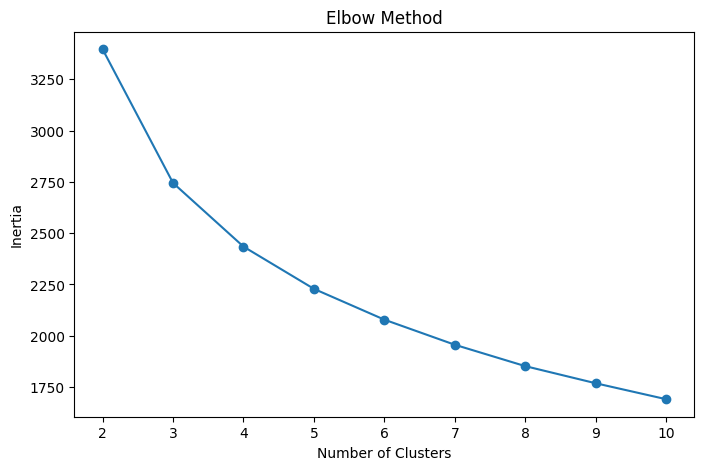

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [43]:
scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

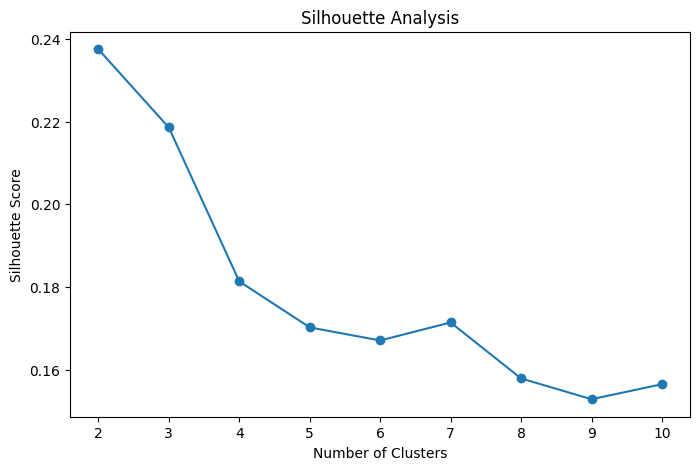

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [45]:
for k in [3, 4]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    df[f"cluster_{k}"] = kmeans.fit_predict(X_scaled)

In [46]:
df.groupby("cluster_3")[feature_cols].mean()

,xg_per90,xa_per90,Standard_Sh/90,Standard_SoT/90,shot_conversion,goals_minus_xg,key_passes_per90,xg_chain_per90,xg_buildup_per90,finishing_share
cluster_3,,,,,,,,,,
0,0.411588,0.261703,2.858132,1.155824,0.139317,0.036662,1.844127,0.819224,0.326932,0.494348
1,0.489244,0.099654,2.674935,1.055974,0.149973,-1.533447,0.869992,0.562651,0.128766,0.896772
2,0.199786,0.147554,1.770955,0.597236,0.093326,-0.546746,1.213585,0.424863,0.169689,0.480338


In [47]:
df.groupby("cluster_4")[feature_cols].mean()

,xg_per90,xa_per90,Standard_Sh/90,Standard_SoT/90,shot_conversion,goals_minus_xg,key_passes_per90,xg_chain_per90,xg_buildup_per90,finishing_share
cluster_4,,,,,,,,,,
0,0.469312,0.093762,2.572388,1.011642,0.149296,-1.490535,0.845454,0.527805,0.120629,0.913906
1,0.197565,0.111835,1.754532,0.584892,0.085987,-0.683957,0.967468,0.379944,0.144056,0.521866
2,0.569975,0.223444,3.380615,1.417846,0.155311,-0.643628,1.576096,0.891024,0.287548,0.643195
3,0.237336,0.244262,2.038962,0.732358,0.115967,-0.046977,1.821534,0.606517,0.268585,0.394955


## 3 Clusters are more suitable in this situation ##

In [48]:

df["cluster_4"].value_counts()

cluster_4
1    139
0    134
3    106
2     65
Name: count, dtype: int64

In [49]:
df["cluster_3"].value_counts()

cluster_3
2    199
1    154
0     91
Name: count, dtype: int64

In [50]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:,0]
df["PC2"] = X_pca[:,1]

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    color="cluster_3",
    hover_name="player",
    hover_data=["team"]
)

fig.show()

In [52]:
fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    color="cluster_4",
    hover_name="player",
    hover_data=["team"]
)

fig.show()

### Elbow analysis suggested either 3 or 4 clusters. While a 4-cluster solution marginally reduced inertia, silhouette analysis favored 3 clusters. PCA visualization further showed that the 4-cluster solution primarily subdivided an existing cluster rather than revealing a distinct new attacker archetype. Therefore, 3 clusters were selected for interpretability and model simplicity. ###

In [59]:
for c in sorted(df["cluster_3"].unique()):

    print(f"\nCluster {c}")

    display(
        df[df["cluster_3"] == c][
            ["player","team"]
        ].head(5)
    )


Cluster 0


,player,team
0,Bukayo Saka,Arsenal
2,Gabriel Martinelli,Arsenal
5,Mikel Merino,Arsenal
10,Eli Junior Kroupi,Bournemouth
47,Jeremy Doku,Manchester City



Cluster 1


,player,team
3,Kai Havertz,Arsenal
7,Viktor Gyökeres,Arsenal
8,Donyell Malen,Aston Villa
9,Ollie Watkins,Aston Villa
11,Evanilson,Bournemouth



Cluster 2


,player,team
1,Eberechi Eze,Arsenal
4,Leandro Trossard,Arsenal
6,Noni Madueke,Arsenal
15,Diego Gómez,Brighton
16,Georginio Rutter,Brighton


In [58]:
df = df.drop(columns=['cluster_4'])

In [65]:
df = df.rename(columns={'cluster_3': 'cluster'})

In [ ]:
cluster_names = {
    0: "Creative Attacker",
    1: "Goalscorer",
    2: "Wide Attacker"
}

df['Archetype'] = df['cluster'].map(cluster_names)

print(df[['player', 'team', 'Archetype']].head())

               player     team          Archetype
0         Bukayo Saka  Arsenal  Creative Attacker
1        Eberechi Eze  Arsenal      Wide Attacker
2  Gabriel Martinelli  Arsenal  Creative Attacker
3         Kai Havertz  Arsenal         Goalscorer
4    Leandro Trossard  Arsenal      Wide Attacker


In [ ]:
fig = px.scatter(
    df, 
    x='PC1', 
    y='PC2',
    color='Archetype',                 
    hover_name='player',         
    hover_data=['team',], 
    title='European Forward Archetypes (PCA Clustering)',
    template='plotly_white',               
    width=1000, 
    height=600
)

fig.update_traces(marker=dict(size=9, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [ ]:
#df.to_csv("../../data/processed/strikers_clusters_v1.csv",index=False)

## This Clustering is Lacking due to not having possesion and passing stats ##